Import Libraries & Setup Dataset Path

In [1]:
# ==================  IMPORT LIBRARIES ==================
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt

#  Set this to the folder that contains all your plant/disease folders
DATASET_PATH = r"C:\Users\SREELAKSHMI\Documents\plant disease detection\PlantVillage\train"


Load Dataset & Preview

Total images: 43444
Disease classes: <StringArray>
[                                'Apple___Apple_scab',
                                  'Apple___Black_rot',
                           'Apple___Cedar_apple_rust',
                                    'Apple___healthy',
                                'Blueberry___healthy',
                  'Cherry_(including_sour)___healthy',
           'Cherry_(including_sour)___Powdery_mildew',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
                        'Corn_(maize)___Common_rust_',
                             'Corn_(maize)___healthy',
                'Corn_(maize)___Northern_Leaf_Blight',
                                  'Grape___Black_rot',
                       'Grape___Esca_(Black_Measles)',
                                    'Grape___healthy',
         'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
           'Orange___Haunglongbing_(Citrus_greening)',
                             'Peach___Bacterial_spot',
              

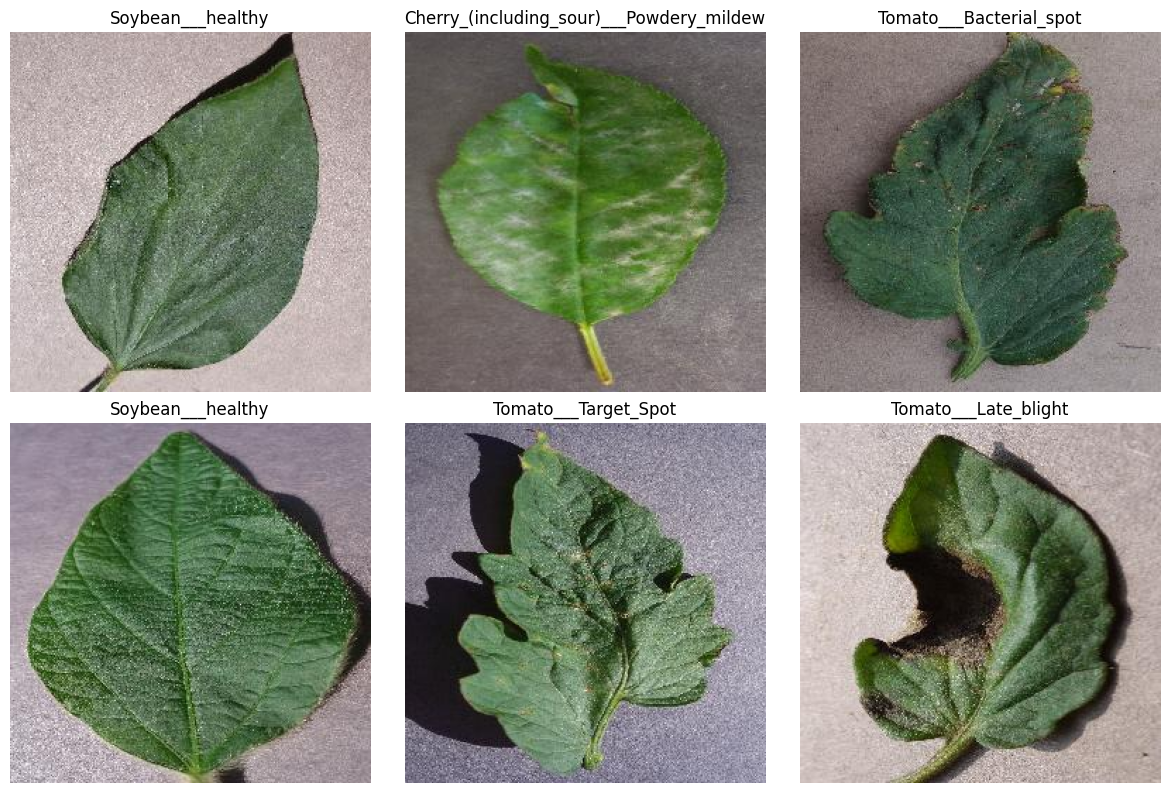

In [2]:
# ==================  LOAD DATASET ==================
data = []

# Loop through each class folder (Apple, Corn, Potato, etc.)
for disease in os.listdir(DATASET_PATH):
    disease_path = os.path.join(DATASET_PATH, disease)
    if os.path.isdir(disease_path):
        # Loop through files inside the folder
        for img_file in os.listdir(disease_path):
            if img_file.lower().endswith((".jpg", ".jpeg", ".png")):
                img_path = os.path.join(disease_path, img_file)
                data.append([img_path, disease])

# Convert to DataFrame
df = pd.DataFrame(data, columns=["image_path", "label"])

# ================== ℹ DATASET INFO ==================
print("Total images:", len(df))
print("Disease classes:", df["label"].unique())

# ================== 🖼 SHOW SAMPLE IMAGES ==================
sample_df = df.sample(min(6, len(df)))
plt.figure(figsize=(12, 8))

for i, row in enumerate(sample_df.itertuples()):
    img = cv2.imread(row.image_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(row.label)
    plt.axis("off")

plt.tight_layout()
plt.show()

Cap Dataset 

In [4]:
# ==================  CAP DATASET ==================
import random
import shutil

SOURCE_PATH =  r"C:\Users\SREELAKSHMI\Documents\plant disease detection\PlantVillage\train" # Original dataset folder
TARGET_PATH = r"C:\Users\SREELAKSHMI\Documents\plant disease detection\capped_dataset\train" # New folder will be created
MAX_IMAGES = 1500 # Max images per class

os.makedirs(TARGET_PATH, exist_ok=True)

for cls in os.listdir(SOURCE_PATH):
    cls_path = os.path.join(SOURCE_PATH, cls)
    if not os.path.isdir(cls_path):
        continue

    images = [img for img in os.listdir(cls_path) if img.lower().endswith((".jpg", ".jpeg", ".png"))]
    print(f"{cls}: {len(images)} images")

    if len(images) > MAX_IMAGES:
        images = random.sample(images, MAX_IMAGES)

    target_cls_path = os.path.join(TARGET_PATH, cls)
    os.makedirs(target_cls_path, exist_ok=True)

    for img in images:
        shutil.copy(os.path.join(cls_path, img), os.path.join(target_cls_path, img))

print(" Dataset capped to 1500 images per class")


Apple___Apple_scab: 504 images
Apple___Black_rot: 496 images
Apple___Cedar_apple_rust: 220 images
Apple___healthy: 1316 images
Blueberry___healthy: 1202 images
Cherry_(including_sour)___healthy: 684 images
Cherry_(including_sour)___Powdery_mildew: 842 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 410 images
Corn_(maize)___Common_rust_: 953 images
Corn_(maize)___healthy: 929 images
Corn_(maize)___Northern_Leaf_Blight: 788 images
Grape___Black_rot: 944 images
Grape___Esca_(Black_Measles): 1107 images
Grape___healthy: 339 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 861 images
Orange___Haunglongbing_(Citrus_greening): 4405 images
Peach___Bacterial_spot: 1838 images
Peach___healthy: 288 images
Pepper,_bell___Bacterial_spot: 797 images
Pepper,_bell___healthy: 1183 images
Potato___Early_blight: 800 images
Potato___healthy: 121 images
Potato___Late_blight: 800 images
Raspberry___healthy: 297 images
Soybean___healthy: 4072 images
Squash___Powdery_mildew: 1468 images
Strawber

Dataset Analysis & Statistics


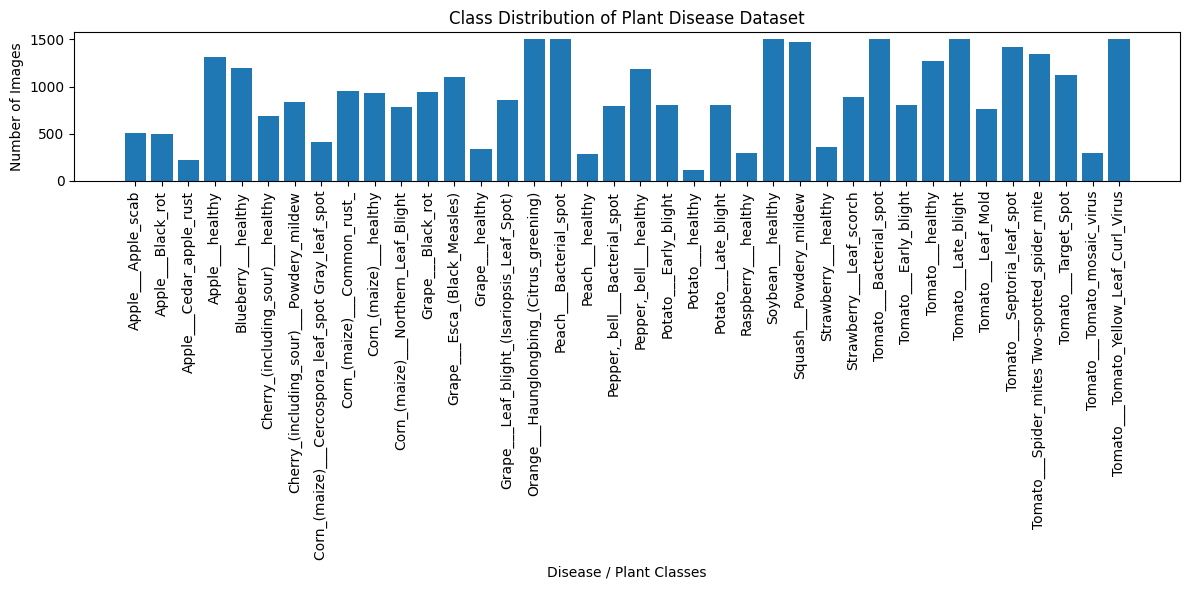


📊 Image Count per Class:
Apple___Apple_scab : 504 images
Apple___Black_rot : 496 images
Apple___Cedar_apple_rust : 220 images
Apple___healthy : 1316 images
Blueberry___healthy : 1202 images
Cherry_(including_sour)___healthy : 684 images
Cherry_(including_sour)___Powdery_mildew : 842 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 410 images
Corn_(maize)___Common_rust_ : 953 images
Corn_(maize)___healthy : 929 images
Corn_(maize)___Northern_Leaf_Blight : 788 images
Grape___Black_rot : 944 images
Grape___Esca_(Black_Measles) : 1107 images
Grape___healthy : 339 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 861 images
Orange___Haunglongbing_(Citrus_greening) : 1500 images
Peach___Bacterial_spot : 1500 images
Peach___healthy : 288 images
Pepper,_bell___Bacterial_spot : 797 images
Pepper,_bell___healthy : 1183 images
Potato___Early_blight : 800 images
Potato___healthy : 121 images
Potato___Late_blight : 800 images
Raspberry___healthy : 297 images
Soybean___healthy : 1500 i

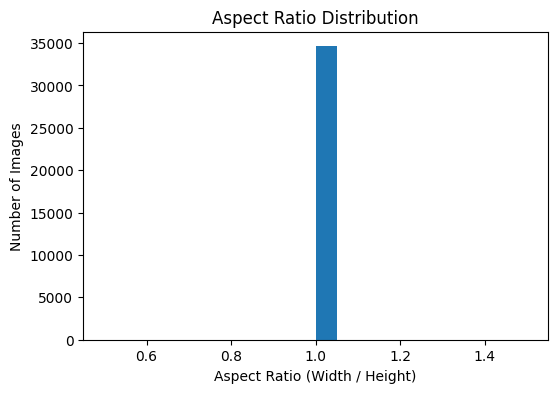

In [6]:
# ==================  DATASET ANALYSIS ==================
from PIL import Image
import numpy as np

# 🔁 Change this to your dataset folder path (capped_dataset or original)
DATASET_PATH = r"C:\Users\SREELAKSHMI\Documents\plant disease detection\capped_dataset\train"

folder_names = []
image_counts = []

widths = []
heights = []
aspect_ratios = []

# Loop through each class folder
for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)
    if os.path.isdir(folder_path):
        count = 0
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                count += 1
                img_path = os.path.join(folder_path, file)
                with Image.open(img_path) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
                    aspect_ratios.append(w / h)
        folder_names.append(folder)
        image_counts.append(count)

# ==================  CLASS DISTRIBUTION ==================
plt.figure(figsize=(12,6))
plt.bar(folder_names, image_counts)
plt.xticks(rotation=90)
plt.xlabel("Disease / Plant Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Plant Disease Dataset")
plt.tight_layout()
plt.show()

print("\n📊 Image Count per Class:")
for name, count in zip(folder_names, image_counts):
    print(f"{name} : {count} images")

# ================== 🖼 RESOLUTION CHECK ==================
unique_sizes = set(zip(widths, heights))
print("\n🖼 Unique Image Resolutions Found:")
for size in unique_sizes:
    print(size)

if len(unique_sizes) == 1:
    print("\n✅ All images have the same resolution.")
else:
    print("\n❌ Images have different resolutions.")

# ================== 📐 WIDTH & HEIGHT STATISTICS ==================
print("\n📐 Width Statistics:")
print(f"Min Width: {min(widths)}")
print(f"Max Width: {max(widths)}")
print(f"Average Width: {np.mean(widths):.2f}")

print("\n📐 Height Statistics:")
print(f"Min Height: {min(heights)}")
print(f"Max Height: {max(heights)}")
print(f"Average Height: {np.mean(heights):.2f}")

# ================== 📏 ASPECT RATIO ANALYSIS ==================
print("\n📏 Aspect Ratio Statistics:")
print(f"Min Aspect Ratio: {min(aspect_ratios):.2f}")
print(f"Max Aspect Ratio: {max(aspect_ratios):.2f}")
print(f"Average Aspect Ratio: {np.mean(aspect_ratios):.2f}")

plt.figure(figsize=(6,4))
plt.hist(aspect_ratios, bins=20)
plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Number of Images")
plt.show()




Import Libraries

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler



Define Transforms

In [8]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


Load Dataset

In [9]:
train_dir = r"C:\Users\SREELAKSHMI\Documents\plant disease detection\capped_dataset\train"
val_dir = r"C:\Users\SREELAKSHMI\Documents\plant disease detection\capped_dataset\val"

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=val_dir, transform=val_transforms)

print("Class mapping:", train_dataset.class_to_idx)


Class mapping: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_bligh

Handle Class Imbalance

In [10]:
targets = [label for _, label in train_dataset.samples]
class_counts = np.bincount(targets)

class_weights = 1. / class_counts
sample_weights = [class_weights[label] for label in targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)



Create DataLoaders

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


Verify Processing Pipeline

In [12]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image tensor type:", type(images))
print("Image value range:", images.min().item(), "to", images.max().item())


c:\Users\SREELAKSHMI\Documents\plant disease detection\myenv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image tensor type: <class 'torch.Tensor'>
Image value range: -2.1179039478302 to 2.640000104904175


Visualize Data Augmentation

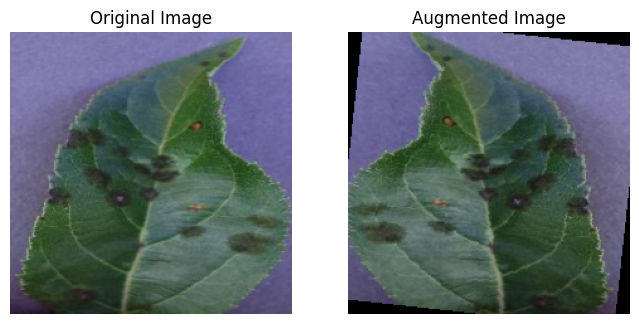

In [13]:
# Load same image twice: one original, one augmented
raw_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

raw_dataset = datasets.ImageFolder(root=train_dir, transform=raw_transform)

raw_img, _ = raw_dataset[0]
aug_img, _ = train_dataset[0]

# Convert tensors to displayable format
raw_img = raw_img.permute(1, 2, 0)
aug_img = aug_img.permute(1, 2, 0)

# De-normalize augmented image for visualization
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])
aug_img = aug_img * std + mean
aug_img = aug_img.clamp(0, 1)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(raw_img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Augmented Image")
plt.imshow(aug_img)
plt.axis("off")

plt.show()
